# §19.12 The Production-Potential Tank Model (SET Model)

This notebook implements the production-potential tank model used in the
**SET Reservoir Model** spreadsheet for generating production profiles.
The model derives exponential decline from a lumped reservoir tank rather
than empirical Arps curve fitting.

**Key equations:**
- Production potential: $q_{\text{pot}} = q_{\text{pot,field}}\,(1 - \alpha\,G_p/G)$
- Well interference: $q_{\text{pot,field}} = q_{\text{pot,well}} \cdot N_w \cdot F^{(N_w-1)}$
- Plateau duration: $\Delta t_p = \frac{G}{\alpha \cdot t_{\text{uptime}}}\left(\frac{1}{q_{p,f}} - \frac{1}{q_{\text{pot,field}}}\right)$
- Decline constant: $m = \alpha \cdot q_{\text{pot,field}} \cdot t_{\text{uptime}} / G$
- Abandonment: $t_{\text{ab}} = \frac{1}{m}\ln\left(\frac{365\,P\,q_{p,f}}{\text{OPEX}}\right) + \Delta t_p + t_{\text{ini}}$


In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 150, "font.size": 10})


## 1. Model Implementation


In [9]:
def set_production_profile(
    G,              # Recoverable reserves [bbl or Sm3]
    q_pot_well,     # Per-well production potential [bbl/d or Sm3/d]
    N_wells,        # Number of production wells
    F,              # Well-interference factor (typ. 0.94)
    alpha,          # Decline-shape parameter (typ. 1.0-1.5)
    q_plateau,      # Design plateau rate [bbl/d or Sm3/d]
    t_uptime,       # Producing days per year [d/yr]
    t_ini=0,        # Build-up / pre-drilling time [yr]
    P_hc=75.0,      # Hydrocarbon price [USD/bbl or USD/Sm3]
    opex=350e6,     # Annual operating cost [USD/yr]
    dt=0.01,        # Time step [yr]
    t_max=40,       # Maximum simulation time [yr]
):
    """Generate a production profile using the production-potential tank model.

    Returns dict with time series and key metrics.
    """
    # Field potential (Eq. 19.17)
    q_pot_field = q_pot_well * N_wells * F ** (N_wells - 1)

    # Check feasibility
    if q_pot_field < q_plateau:
        raise ValueError(
            f"Field potential ({q_pot_field:.0f}) < plateau rate ({q_plateau:.0f}). "
            f"Increase wells or reduce plateau."
        )

    # Plateau duration (Eq. 19.20)
    delta_tp = (G / (alpha * t_uptime)) * (1/q_plateau - 1/q_pot_field)

    # Decline constant (Eq. 19.21)
    m = alpha * q_pot_field * t_uptime / G

    # Abandonment time (Eq. 19.22)
    revenue_ratio = 365 * P_hc * q_plateau / opex
    if revenue_ratio > 1:
        t_abandon = (1/m) * np.log(revenue_ratio) + delta_tp + t_ini
    else:
        t_abandon = t_ini  # Never profitable

    # Generate time series
    t = np.arange(0, min(t_max, t_abandon + 2), dt)
    q = np.zeros_like(t)

    for i, ti in enumerate(t):
        if ti < t_ini:
            q[i] = 0.0
        elif ti < t_ini + delta_tp:
            q[i] = q_plateau
        else:
            q[i] = q_plateau * np.exp(-m * (ti - delta_tp - t_ini))

    # Cumulative production
    Gp = np.cumsum(q) * dt * t_uptime

    # Production potential curve
    q_pot = q_pot_field * (1 - alpha * Gp / G)
    q_pot = np.maximum(q_pot, 0)

    return {
        "t": t,
        "q": q,
        "Gp": Gp,
        "q_pot": q_pot,
        "q_pot_field": q_pot_field,
        "delta_tp": delta_tp,
        "m": m,
        "t_abandon": t_abandon,
        "recovery_factor_at_abandon": Gp[t <= t_abandon][-1] / G if t_abandon > t_ini else 0,
    }


## 2. Ultima Thule Base Case

Using representative parameters from the exercise.


In [10]:
# Ultima Thule oil-case parameters
params = dict(
    G=270e6,           # Recoverable reserves [bbl]
    q_pot_well=18000,  # Per-well potential [bbl/d]
    N_wells=12,        # Production wells
    F=0.94,            # Well-interference factor
    alpha=1.10,        # Decline-shape parameter
    q_plateau=100000,  # Design plateau rate [bbl/d]
    t_uptime=355,      # Producing days/yr
    t_ini=1.0,         # 1-year build-up
    P_hc=75.0,         # Oil price [USD/bbl]
    opex=350e6,        # Annual OPEX [USD/yr]
)

result = set_production_profile(**params)

print(f"Field potential:     {result['q_pot_field']:,.0f} bbl/d")
print(f"Plateau duration:    {result['delta_tp']:.2f} yr")
print(f"Decline rate (m):    {result['m']:.4f} /yr ({result['m']*100:.1f} %/yr)")
print(f"Abandonment time:    {result['t_abandon']:.1f} yr")
print(f"Recovery at abandon: {result['recovery_factor_at_abandon']:.1%}")


Field potential:     109,360 bbl/d
Plateau duration:    0.59 yr
Decline rate (m):    0.1582 /yr (15.8 %/yr)
Abandonment time:    14.6 yr
Recovery at abandon: 80.3%


## 2b. Full SET Parameter Derivation Workflow

The SET spreadsheet requires students to supply ~30 inputs. Most are
**not independent** — they are derived from a few fundamental reservoir
and facility assumptions. This section shows how the base-case values
above are obtained from first principles.

### Step 1: Volumetrics → Reserves

$$G = \text{STOIIP} \times RF$$

### Step 2: Well design → Individual well rate

The per-well potential $q_{\text{pot,well}}$ comes from IPR/VLP matching
(Chapter 4). It depends on reservoir pressure, PI, tubing size, and
artificial lift.

### Step 3: Well count → Field potential

$q_{\text{pot,field}} = q_{\text{pot,well}} \cdot N_w \cdot F^{(N_w-1)}$

### Step 4: Regularity → Uptime

$t_{\text{uptime}} = 365 \times \text{regularity}$

### Step 5: Capacity check → Plateau rate

The plateau rate is the **minimum** of field potential and all capacity
constraints (oil, gas, water, liquid handling, export pipeline).

### Step 6: Offtake guard-rail

Offtake fraction = $q_{\text{plateau}} \times 365 / G$ should be 9–13 %
for oil fields.


In [11]:
# ============================================================
# STEP 1: Volumetrics → Reserves
# ============================================================
STOIIP = 600e6       # Stock-tank oil initially in place [bbl]
RF = 0.45            # Recovery factor (waterflood, good reservoir)
G = STOIIP * RF      # Recoverable reserves [bbl]

print("─── Step 1: Volumetrics ───")
print(f"  STOIIP:           {STOIIP/1e6:.0f} MMbbl")
print(f"  Recovery factor:  {RF:.0%}")
print(f"  Reserves (G):     {G/1e6:.0f} MMbbl")

# ============================================================
# STEP 2: Well design → Per-well rate
# ============================================================
# From IPR/VLP matching (Ch4): PI × drawdown × completion efficiency
PI = 25.0            # Productivity index [bbl/d/psi]
drawdown = 800       # Design drawdown [psi]
skin = 0.0           # Skin factor (0 = ideal completion)
q_pot_well = PI * drawdown * (1 / (1 + skin))  # Simplified

# Override with known value if available from well test/design
q_pot_well = 18000   # bbl/d (from exercise)

print(f"\n─── Step 2: Well rate ───")
print(f"  q_pot_well:       {q_pot_well:,.0f} bbl/d")

# ============================================================
# STEP 3: Well count and spacing
# ============================================================
N_producers = 12
N_water_inj = 5      # 1 injector per 2-3 producers (pattern flood)
N_gas_inj = 0
F = 0.94             # Well-interference factor (shared pipeline)

# Well spacing from drainage area
field_area_km2 = 25.0                        # Field area [km²]
A_per_well = field_area_km2 / N_producers    # Drainage area per well [km²]
well_spacing_m = np.sqrt(A_per_well * 1e6)   # Square pattern [m]

# Field potential
q_pot_field = q_pot_well * N_producers * F ** (N_producers - 1)

# Reserves per original producer
reserves_per_OP = G / N_producers

print(f"\n─── Step 3: Well count & spacing ───")
print(f"  Producers:        {N_producers}")
print(f"  Water injectors:  {N_water_inj}")
print(f"  Gas injectors:    {N_gas_inj}")
print(f"  Well spacing:     {well_spacing_m:.0f} m")
print(f"  Reserves/OP:      {reserves_per_OP/1e6:.1f} MMbbl/well")
print(f"  Field potential:  {q_pot_field:,.0f} bbl/d")

# ============================================================
# STEP 4: Regularity → Uptime
# ============================================================
regularity = 0.97      # 97% uptime (good NCS platform)
t_uptime = 365 * regularity

# First-year production efficiency (commissioning ramp)
prod_eff_yr1 = 0.50    # 50% efficiency first year (typical)

print(f"\n─── Step 4: Regularity ───")
print(f"  Regularity:       {regularity:.0%}")
print(f"  Uptime:           {t_uptime:.0f} d/yr")
print(f"  1st-year eff:     {prod_eff_yr1:.0%}")


─── Step 1: Volumetrics ───
  STOIIP:           600 MMbbl
  Recovery factor:  45%
  Reserves (G):     270 MMbbl

─── Step 2: Well rate ───
  q_pot_well:       18,000 bbl/d

─── Step 3: Well count & spacing ───
  Producers:        12
  Water injectors:  5
  Gas injectors:    0
  Well spacing:     1443 m
  Reserves/OP:      22.5 MMbbl/well
  Field potential:  109,360 bbl/d

─── Step 4: Regularity ───
  Regularity:       97%
  Uptime:           354 d/yr
  1st-year eff:     50%


In [ ]:
# ============================================================
# STEP 5: Capacity constraints → Plateau rate
# ============================================================
# Facility design capacities
cap_oil = 120000       # Oil handling [bbl/d]
cap_gas = 5.0e6        # Gas handling [Sm3/d] — convert via GOR
cap_water = 80000      # Water treatment [bbl/d]
cap_liquid = 150000    # Total liquid (oil + water) [bbl/d]
cap_export = 110000    # Export pipeline limit [bbl/d]

# At plateau, water cut is low → oil is the binding constraint
# GOR constraint: max_oil_from_gas = cap_gas / GOR
GOR = 150              # Gas-oil ratio [Sm3/Sm3] at plateau (solution gas)
# Convert GOR to Sm3/bbl: 1 bbl = 0.159 m3
max_oil_from_gas = cap_gas / (GOR * 0.159)  # equivalent oil rate limited by gas

# The plateau rate is the MINIMUM of all constraints
q_plateau_candidates = {
    "Field potential": q_pot_field,
    "Oil capacity": cap_oil,
    "Gas capacity (oil equiv)": max_oil_from_gas,
    "Water capacity (WC~0)": cap_liquid,  # At low WC, liquid ≈ oil
    "Export pipeline": cap_export,
}

print("─── Step 5: Capacity constraints ───")
print(f"  {'Constraint':<25} {'Limit [bbl/d]':>15}  Binding?")
print(f"  {'─'*60}")

q_plateau = min(q_plateau_candidates.values())
for name, val in q_plateau_candidates.items():
    binding = " ← BINDING" if val == q_plateau else ""
    print(f"  {name:<25} {val:>15,.0f}{binding}")

# In practice, design plateau is chosen as a round number at/below binding
q_plateau = 100000  # Design choice [bbl/d]
print(f"\n  Design plateau rate:   {q_plateau:,.0f} bbl/d")

# --- Capacity constraint visualisation ---
names = list(q_plateau_candidates.keys())
values = [v/1000 for v in q_plateau_candidates.values()]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d32f2f" if v == min(values) else "#1976d2" for v in values]
bars = ax.barh(names, values, color=colors, alpha=0.8)
ax.axvline(q_plateau/1000, color="k", ls="--", lw=1.5, label=f"Design plateau = {q_plateau/1000:.0f} kbbl/d")
ax.set_xlabel("Rate limit [kbbl/d]")
ax.set_title("Capacity Constraints — Which One Binds?")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, axis="x", alpha=0.3)
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{v:.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/ch19_s07_capacity_constraints.png", dpi=150, bbox_inches="tight")
plt.show()


─── Step 5: Capacity constraints ───
  Constraint                  Limit [bbl/d]  Binding?
  ────────────────────────────────────────────────────────────
  Field potential                   109,360 ← BINDING
  Oil capacity                      120,000
  Gas capacity (oil equiv)          209,644
  Water capacity (WC~0)             150,000
  Export pipeline                   110,000

  Design plateau rate:   100,000 bbl/d


In [13]:
# ============================================================
# STEP 6: Offtake guard-rail check
# ============================================================
offtake_fraction = (q_plateau * 365) / G
offtake_pct = offtake_fraction * 100

print("─── Step 6: Offtake guard-rail ───")
print(f"  Annual plateau offtake:  {q_plateau * 365 / 1e6:.1f} MMbbl/yr")
print(f"  Offtake fraction:        {offtake_pct:.1f}% of reserves per year")

if 9 <= offtake_pct <= 13:
    print(f"  ✓ Within typical range (9–13%) — OK")
elif offtake_pct < 9:
    print(f"  ⚠ Below 9% — field may be under-developed (too few wells?)")
else:
    print(f"  ⚠ Above 13% — aggressive offtake, may shorten plateau")
    print(f"    Consider increasing reserves estimate or reducing plateau")

# Reserves per OP check
print(f"\n  Reserves per producer:   {reserves_per_OP/1e6:.1f} MMbbl/well")
if reserves_per_OP/1e6 < 5:
    print(f"  ⚠ Below 5 MMbbl/well — possible over-drilling")
elif reserves_per_OP/1e6 > 30:
    print(f"  ⚠ Above 30 MMbbl/well — possible under-drilling")
else:
    print(f"  ✓ Within typical range (5–30 MMbbl/well) — OK")


─── Step 6: Offtake guard-rail ───
  Annual plateau offtake:  36.5 MMbbl/yr
  Offtake fraction:        13.5% of reserves per year
  ⚠ Above 13% — aggressive offtake, may shorten plateau
    Consider increasing reserves estimate or reducing plateau

  Reserves per producer:   22.5 MMbbl/well
  ✓ Within typical range (5–30 MMbbl/well) — OK


In [14]:
# ============================================================
# STEP 7: First-year production efficiency (ramp)
# ============================================================
# The SET model uses a flat t_ini delay. In reality, production ramps
# during the first year due to commissioning, well hookup, and testing.

# Simple ramp model: produce at (prod_eff_yr1 × q_plateau) during year 1
first_year_production = q_plateau * prod_eff_yr1 * t_uptime
steady_year_production = q_plateau * t_uptime
lost_production = steady_year_production - first_year_production

print("─── Step 7: First-year ramp effect ───")
print(f"  Production efficiency 1st year: {prod_eff_yr1:.0%}")
print(f"  Effective 1st year output:      {first_year_production/1e6:.1f} MMbbl")
print(f"  Steady-state annual output:     {steady_year_production/1e6:.1f} MMbbl")
print(f"  Lost production (vs full year): {lost_production/1e6:.1f} MMbbl")
print(f"\n  SET approximation: t_ini = {1.0} yr delay (all-or-nothing)")
print(f"  More realistic:    ramp over 6–9 months with phased well start-up")


─── Step 7: First-year ramp effect ───
  Production efficiency 1st year: 50%
  Effective 1st year output:      17.7 MMbbl
  Steady-state annual output:     35.4 MMbbl
  Lost production (vs full year): 17.7 MMbbl

  SET approximation: t_ini = 1.0 yr delay (all-or-nothing)
  More realistic:    ramp over 6–9 months with phased well start-up


In [15]:
# ============================================================
# STEP 8: Gas-cap and NGL parameters (for gas-bearing fields)
# ============================================================
# These apply when the field has a gas cap above the oil zone

original_gas_cap = 15e9     # Original gas-cap volume [Sm3]
gas_reinjected = 10e9       # Gas reinjected for pressure maintenance [Sm3]
shrinkage_fuel_pct = 0.05   # 5% of gross gas consumed as fuel/shrinkage
start_blowdown_year = 12    # Year gas-cap production begins

# NGL fractions (typical NCS rich gas)
ngl_C3_pct = 3.5            # Propane [mol% of gross gas]
ngl_C4_pct = 2.0            # Butane [mol%]
ngl_C5plus_pct = 1.0        # C5+ condensate [mol%]

# Sales gas = gross - reinjected - fuel - NGL
gross_gas_available = original_gas_cap - gas_reinjected
gas_after_fuel = gross_gas_available * (1 - shrinkage_fuel_pct)
ngl_fraction = (ngl_C3_pct + ngl_C4_pct + ngl_C5plus_pct) / 100
sales_gas = gas_after_fuel * (1 - ngl_fraction)

print("─── Step 8: Gas-cap & NGL parameters ───")
print(f"  Original gas cap:     {original_gas_cap/1e9:.1f} GSm³")
print(f"  Gas reinjected:       {gas_reinjected/1e9:.1f} GSm³")
print(f"  Net gas for blowdown: {gross_gas_available/1e9:.1f} GSm³")
print(f"  After fuel/shrinkage: {gas_after_fuel/1e9:.1f} GSm³")
print(f"  NGL extracted:        {ngl_fraction:.1%} (C3={ngl_C3_pct}%, C4={ngl_C4_pct}%, C5+={ngl_C5plus_pct}%)")
print(f"  Sales gas:            {sales_gas/1e9:.2f} GSm³")
print(f"  Blowdown starts:      Year {start_blowdown_year}")
print(f"\n  Note: Associated gas during oil production = q_oil × GOR = {q_plateau * GOR * 0.159 / 1e6:.2f} MSm³/d")


─── Step 8: Gas-cap & NGL parameters ───
  Original gas cap:     15.0 GSm³
  Gas reinjected:       10.0 GSm³
  Net gas for blowdown: 5.0 GSm³
  After fuel/shrinkage: 4.8 GSm³
  NGL extracted:        6.5% (C3=3.5%, C4=2.0%, C5+=1.0%)
  Sales gas:            4.44 GSm³
  Blowdown starts:      Year 12

  Note: Associated gas during oil production = q_oil × GOR = 2.38 MSm³/d


## 2c. Parameter Summary Table

All SET inputs derived from the workflow above:


In [16]:
# Summary table of all SET parameters
print("╔══════════════════════════════════════════════════════════════════╗")
print("║          SET SPREADSHEET INPUT PARAMETERS — DERIVED            ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  STOIIP                    {STOIIP/1e6:>10.0f} MMbbl               ║")
print(f"║  Recovery factor           {RF:>10.0%}                     ║")
print(f"║  Reserves (G)              {G/1e6:>10.0f} MMbbl               ║")
print(f"║  Drive mechanism           {'Waterflood':>10s} (α=1.10)         ║")
print(f"║  α (decline shape)         {1.10:>10.2f}                     ║")
print(f"║──────────────────────────────────────────────────────────────────║")
print(f"║  Nr oil producers          {N_producers:>10d}                     ║")
print(f"║  Nr water injectors        {N_water_inj:>10d}                     ║")
print(f"║  Nr gas injectors          {N_gas_inj:>10d}                     ║")
print(f"║  Well spacing              {well_spacing_m:>10.0f} m                  ║")
print(f"║  q_pot_well                {q_pot_well:>10,d} bbl/d              ║")
print(f"║  Reserves/OP               {reserves_per_OP/1e6:>10.1f} MMbbl/well         ║")
print(f"║──────────────────────────────────────────────────────────────────║")
print(f"║  Regularity                {regularity:>10.0%}                     ║")
print(f"║  Uptime (t_uptime)         {t_uptime:>10.0f} d/yr                ║")
print(f"║  Prod. efficiency yr 1     {prod_eff_yr1:>10.0%}                     ║")
print(f"║──────────────────────────────────────────────────────────────────║")
print(f"║  Oil process capacity      {cap_oil:>10,d} bbl/d              ║")
print(f"║  Gas handling capacity     {cap_gas/1e6:>10.1f} MSm³/d             ║")
print(f"║  Water capacity            {cap_water:>10,d} bbl/d              ║")
print(f"║  Liquid capacity           {cap_liquid:>10,d} bbl/d              ║")
print(f"║  Export capacity           {cap_export:>10,d} bbl/d              ║")
print(f"║  Design plateau rate       {q_plateau:>10,d} bbl/d              ║")
print(f"║──────────────────────────────────────────────────────────────────║")
print(f"║  Offtake fraction          {offtake_pct:>10.1f} %/yr                ║")
print(f"║  Field potential           {q_pot_field:>10,.0f} bbl/d              ║")
print(f"║──────────────────────────────────────────────────────────────────║")
print(f"║  Original gas cap          {original_gas_cap/1e9:>10.1f} GSm³                ║")
print(f"║  Gas reinjected            {gas_reinjected/1e9:>10.1f} GSm³                ║")
print(f"║  NGL (C3+C4+C5+)           {ngl_fraction*100:>10.1f} mol%                ║")
print(f"║  Blowdown start year       {start_blowdown_year:>10d}                     ║")
print(f"║  Oil price                 {75.0:>10.0f} USD/bbl             ║")
print(f"║  Annual OPEX               {350:>10d} MUSD/yr             ║")
print("╚══════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║          SET SPREADSHEET INPUT PARAMETERS — DERIVED            ║
╠══════════════════════════════════════════════════════════════════╣
║  STOIIP                           600 MMbbl               ║
║  Recovery factor                  45%                     ║
║  Reserves (G)                     270 MMbbl               ║
║  Drive mechanism           Waterflood (α=1.10)         ║
║  α (decline shape)               1.10                     ║
║──────────────────────────────────────────────────────────────────║
║  Nr oil producers                  12                     ║
║  Nr water injectors                 5                     ║
║  Nr gas injectors                   0                     ║
║  Well spacing                    1443 m                  ║
║  q_pot_well                    18,000 bbl/d              ║
║  Reserves/OP                     22.5 MMbbl/well         ║
║─────────────────────────────────────────────────

> **Student exercise.** Go back to the SET spreadsheet and verify that
> changing STOIIP, RF, or well count propagates correctly through
> Steps 1–6 above. The offtake fraction should remain in the 9–13 %
> window; if not, adjust the plateau rate or well count.


## 3. Production Profile Plot


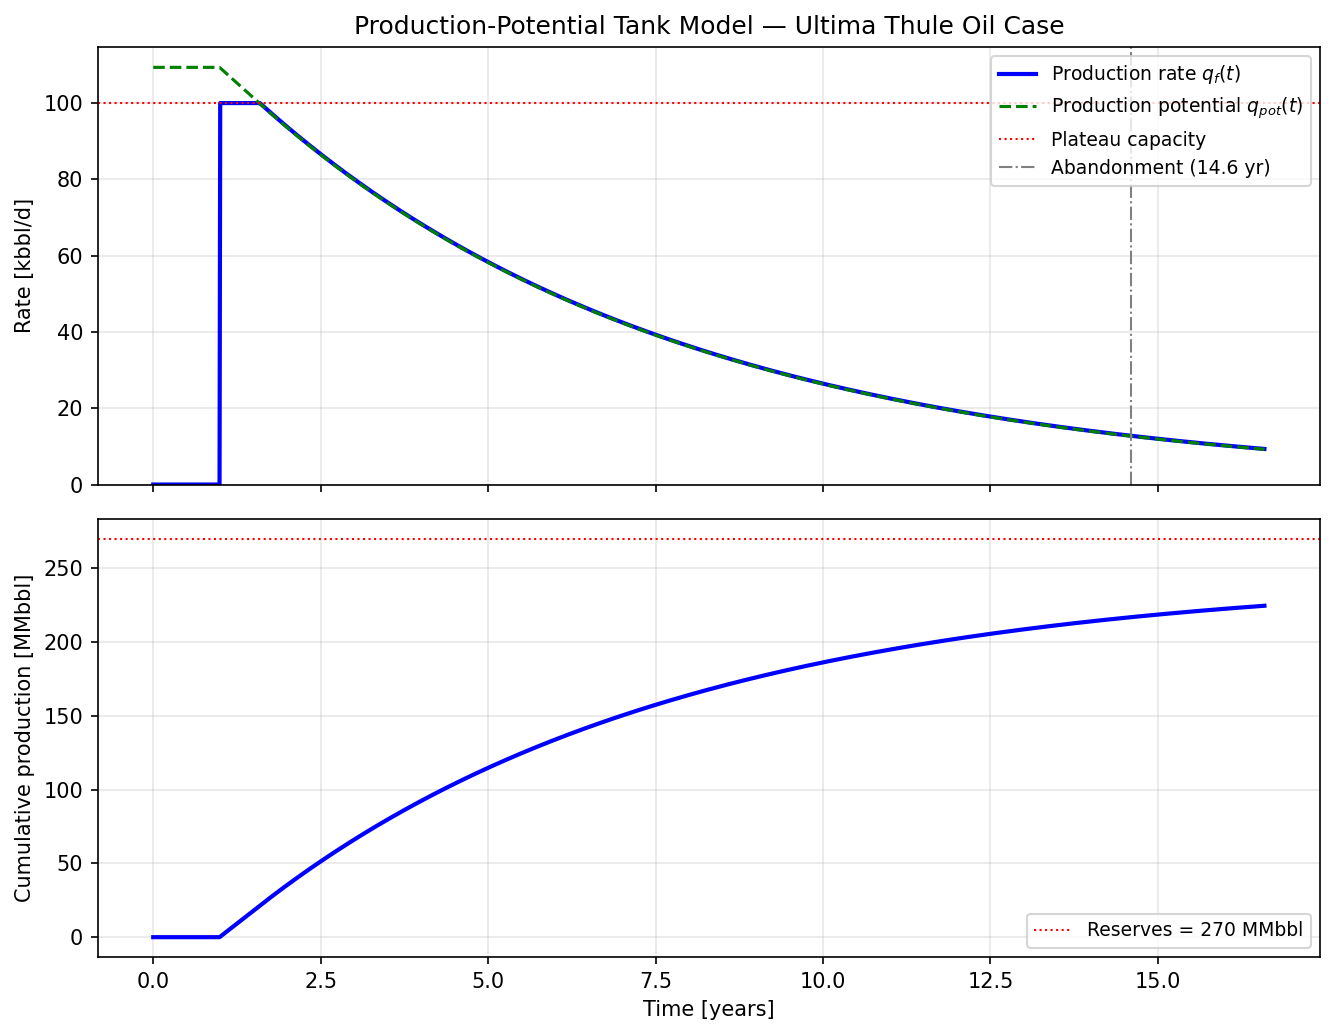

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

t = result["t"]
q = result["q"] / 1000  # kbbl/d
q_pot = result["q_pot"] / 1000

# Upper: production rate and potential
ax1.plot(t, q, "b-", lw=2, label="Production rate $q_f(t)$")
ax1.plot(t, q_pot, "g--", lw=1.5, label="Production potential $q_{pot}(t)$")
ax1.axhline(params["q_plateau"]/1000, color="r", ls=":", lw=1, label="Plateau capacity")
ax1.axvline(result["t_abandon"], color="gray", ls="-.", lw=1, label=f"Abandonment ({result['t_abandon']:.1f} yr)")
ax1.set_ylabel("Rate [kbbl/d]")
ax1.set_title("Production-Potential Tank Model — Ultima Thule Oil Case")
ax1.legend(loc="upper right", fontsize=9)
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)

# Lower: cumulative production
ax2.plot(t, result["Gp"] / 1e6, "b-", lw=2)
ax2.axhline(params["G"] / 1e6, color="r", ls=":", lw=1, label=f"Reserves = {params['G']/1e6:.0f} MMbbl")
ax2.set_xlabel("Time [years]")
ax2.set_ylabel("Cumulative production [MMbbl]")
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/ch19_s07_set_model.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Sensitivity: Effect of Well Count

The well-interference factor $F^{(N_w-1)}$ means that adding wells
has diminishing returns. Let's explore how plateau duration and decline
rate change with well count.


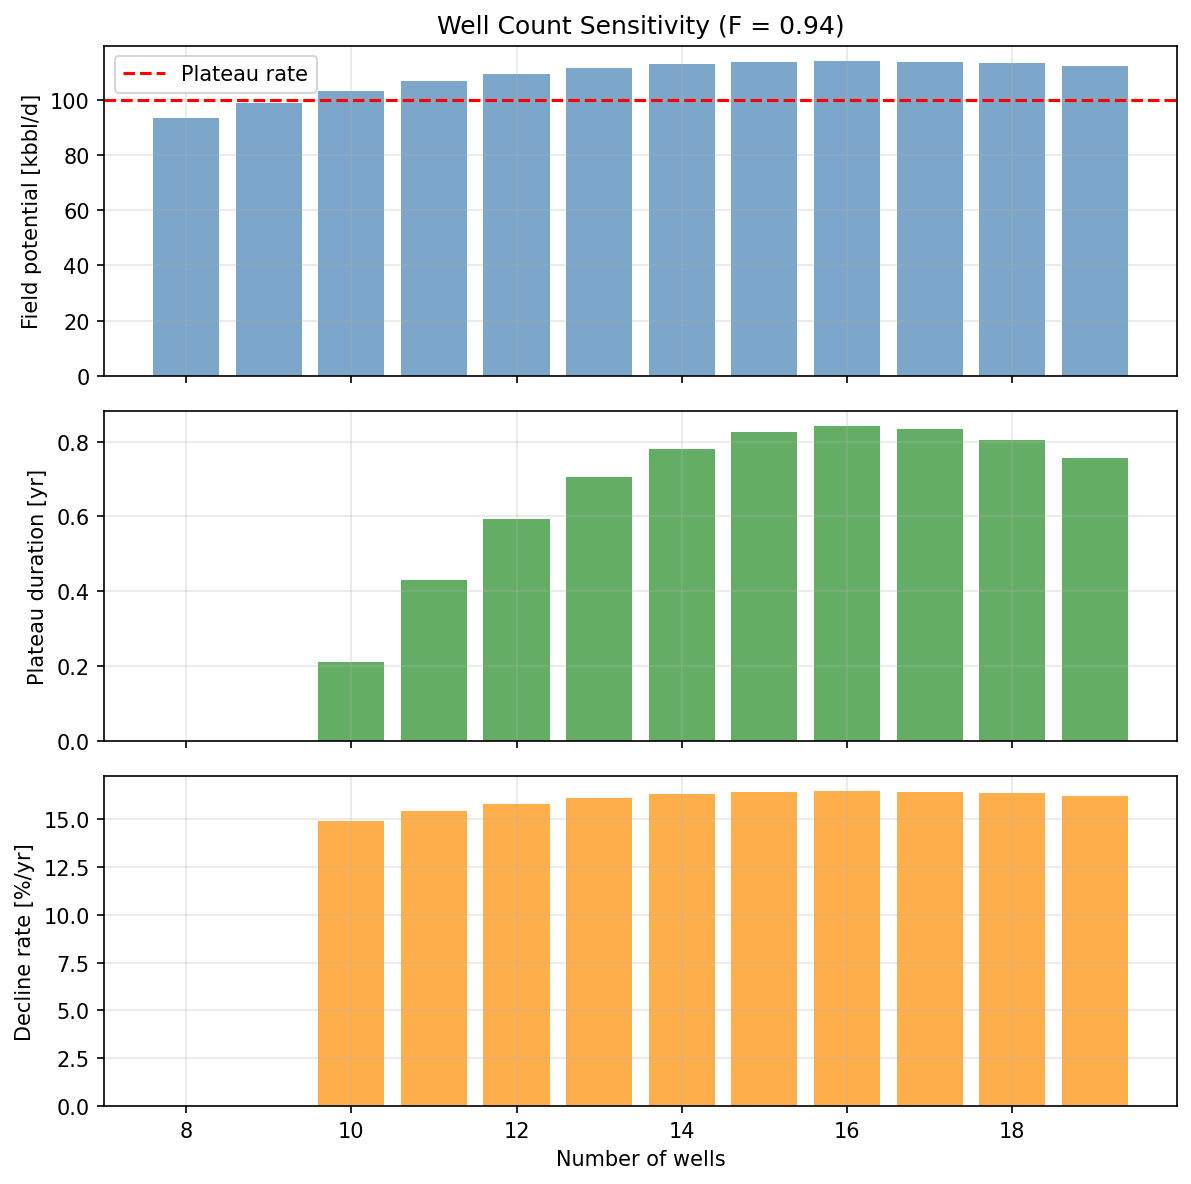

In [18]:
well_counts = np.arange(8, 20)
plateau_durations = []
decline_rates = []
field_potentials = []

for nw in well_counts:
    q_pot_f = params["q_pot_well"] * nw * params["F"] ** (nw - 1)
    field_potentials.append(q_pot_f)
    if q_pot_f > params["q_plateau"]:
        dt_p = (params["G"] / (params["alpha"] * params["t_uptime"])) * (
            1/params["q_plateau"] - 1/q_pot_f
        )
        m_val = params["alpha"] * q_pot_f * params["t_uptime"] / params["G"]
    else:
        dt_p = 0
        m_val = np.nan
    plateau_durations.append(dt_p)
    decline_rates.append(m_val * 100 if not np.isnan(m_val) else np.nan)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

ax1.bar(well_counts, np.array(field_potentials)/1000, color="steelblue", alpha=0.7)
ax1.axhline(params["q_plateau"]/1000, color="r", ls="--", label="Plateau rate")
ax1.set_ylabel("Field potential [kbbl/d]")
ax1.set_title("Well Count Sensitivity (F = 0.94)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(well_counts, plateau_durations, color="forestgreen", alpha=0.7)
ax2.set_ylabel("Plateau duration [yr]")
ax2.grid(True, alpha=0.3)

ax3.bar(well_counts, decline_rates, color="darkorange", alpha=0.7)
ax3.set_xlabel("Number of wells")
ax3.set_ylabel("Decline rate [%/yr]")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/ch19_s07_well_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Comparison with Arps Exponential Decline

The production-potential model generates an exponential decline
identical to Arps with $b = 0$ and $D_i = m$. Let's verify this
and also compare with a hyperbolic Arps fit ($b = 0.5$).


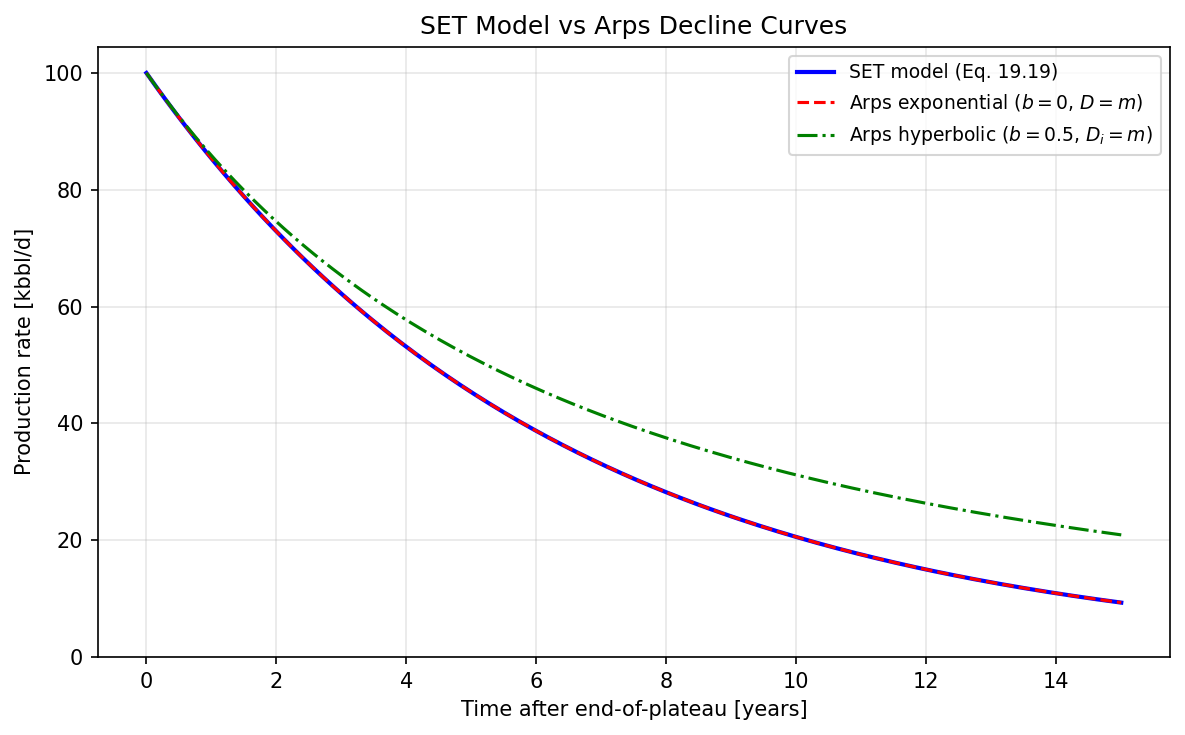

Cumulative after 10 yr decline:
  SET/Arps exponential: 178.3 MMbbl
  Arps hyperbolic b=0.5: 198.2 MMbbl
  Difference: 19.9 MMbbl (11.2% more)


In [19]:
# Time after end-of-plateau
t_decline = np.linspace(0, 15, 200)

# SET model (exponential from production potential)
m = result["m"]
q_set = params["q_plateau"] * np.exp(-m * t_decline)

# Arps exponential (b=0) — identical by construction
q_arps_exp = params["q_plateau"] * np.exp(-m * t_decline)

# Arps hyperbolic (b=0.5) — different behaviour
b = 0.5
q_arps_hyp = params["q_plateau"] / (1 + b * m * t_decline) ** (1/b)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_decline, q_set/1000, "b-", lw=2, label="SET model (Eq. 19.19)")
ax.plot(t_decline, q_arps_exp/1000, "r--", lw=1.5, label="Arps exponential ($b=0$, $D=m$)")
ax.plot(t_decline, q_arps_hyp/1000, "g-.", lw=1.5, label="Arps hyperbolic ($b=0.5$, $D_i=m$)")
ax.set_xlabel("Time after end-of-plateau [years]")
ax.set_ylabel("Production rate [kbbl/d]")
ax.set_title("SET Model vs Arps Decline Curves")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("../figures/ch19_s07_arps_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Cumulative comparison at 10 years
Gp_set = params["q_plateau"] * params["t_uptime"] * (1 - np.exp(-m*10)) / m
Gp_hyp = params["q_plateau"] * params["t_uptime"] / ((1-b)*m) * (
    1 - (1 + b*m*10)**((b-1)/b)
)
print(f"Cumulative after 10 yr decline:")
print(f"  SET/Arps exponential: {Gp_set/1e6:.1f} MMbbl")
print(f"  Arps hyperbolic b=0.5: {Gp_hyp/1e6:.1f} MMbbl")
print(f"  Difference: {(Gp_hyp-Gp_set)/1e6:.1f} MMbbl ({(Gp_hyp/Gp_set-1)*100:.1f}% more)")


## 6. Drainage-Strategy Sensitivity

The $\alpha$ parameter captures drive-mechanism strength. Higher $\alpha$
means steeper decline but also shorter plateau — a trade-off the student
explores in the SET spreadsheet.


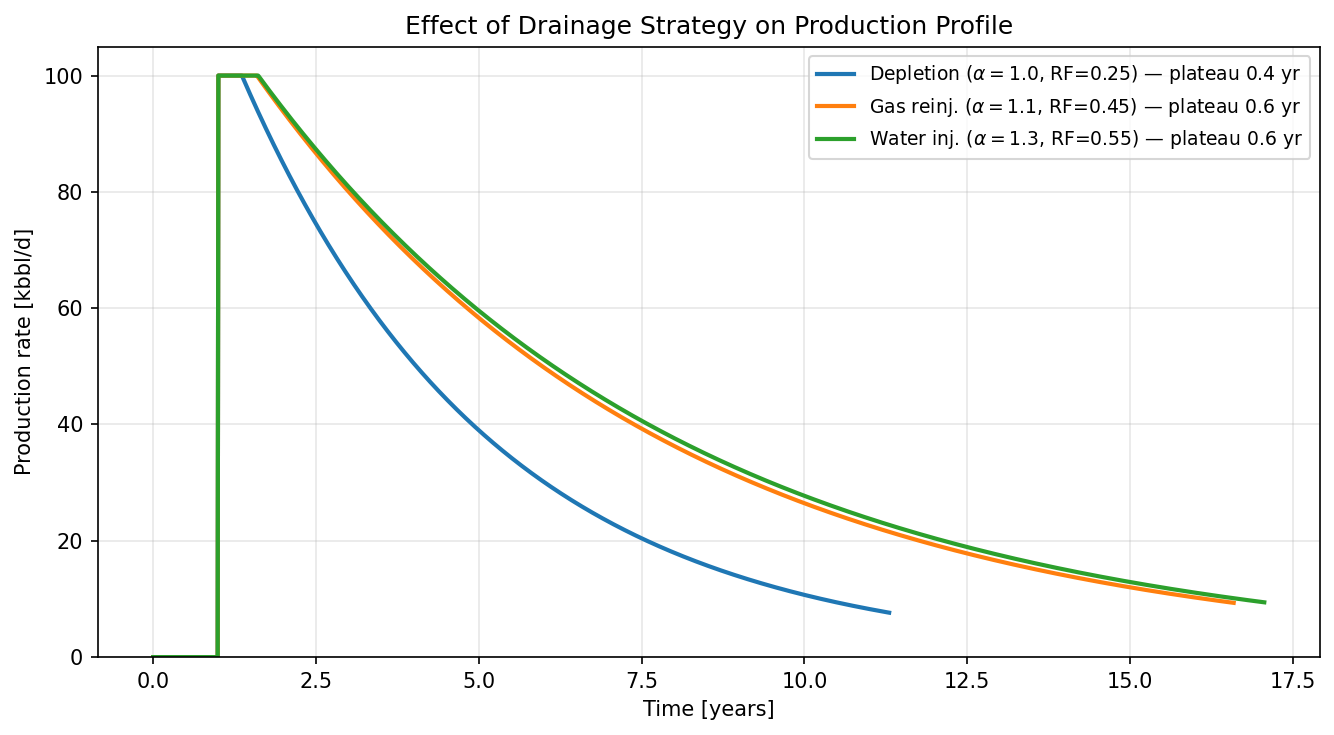

In [20]:
strategies = {
    "Depletion ($\\alpha=1.0$, RF=0.25)": {"alpha": 1.0, "G": 600e6 * 0.25},
    "Gas reinj. ($\\alpha=1.1$, RF=0.45)": {"alpha": 1.1, "G": 600e6 * 0.45},
    "Water inj. ($\\alpha=1.3$, RF=0.55)": {"alpha": 1.3, "G": 600e6 * 0.55},
}

fig, ax = plt.subplots(figsize=(9, 5))

for label, s in strategies.items():
    p = params.copy()
    p["alpha"] = s["alpha"]
    p["G"] = s["G"]
    try:
        r = set_production_profile(**p)
        ax.plot(r["t"], r["q"]/1000, lw=2, label=f"{label} — plateau {r['delta_tp']:.1f} yr")
    except ValueError as e:
        print(f"  {label}: {e}")

ax.set_xlabel("Time [years]")
ax.set_ylabel("Production rate [kbbl/d]")
ax.set_title("Effect of Drainage Strategy on Production Profile")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("../figures/ch19_s07_drainage_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

The production-potential tank model provides a **closed-form analytical**
production profile that:

1. Derives the decline rate from physical principles (tank depletion)
2. Predicts plateau duration from the potential-equals-capacity crossing
3. Accounts for well interference in shared pipeline networks
4. Gives identical results to Arps exponential decline ($b=0$)
5. Is the theoretical basis of the SET spreadsheet used in Exercise 2

For real fields with heterogeneous reservoirs and complex drive mechanisms,
Arps hyperbolic decline ($b > 0$) or full reservoir simulation is needed
for production forecasting. The SET model is best suited for **concept
screening** where the aim is rapid comparison of design alternatives.
